<a href="https://colab.research.google.com/github/Yassin00-WEB/My-first-project/blob/main/TP_Programmation_lin%C3%A9aire_sensibilit%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

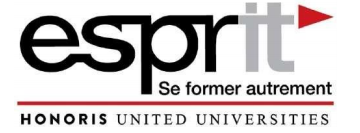



##### **UP Mathématiques - Année universitaire 2025/2026**

# **TP Programmation Linéaire : Résolution numérique & Analyse de sensibilité**

### **Objectifs du TP :**

 L’objectif général du TP est de **résoudre numériquement un problème de programmation linéaire** en utilisant Python et les solveurs intégrés
 de la bibliothèque **scipy.optimize.linprog** (HiGHS ou Simplex). Les étudiants développeront une compréhension approfondie des étapes
 nécessaires à la formulation et à la résolution de ce type de problème, tout en explorant l’analyse post-optimale et l’étude de sensibilité.

 *Objectifs spécifiques:*

 1. Introduire les étudiants aux solveurs de SciPy (par exemple HiGHS ou Simplex).
 2. Comprendre l'interprétation des résultats fournis par les solveurs, y compris les valeurs optimales des variables, le coût optimal, et les
 marges (slack).
 3. Apprendre à analyser les coefficients de dualité (prix ombrage ou shadow prices) pour étudier l'impact de changements dans les
 ressources disponibles.
 4. Étudier l'évolution de la solution optimale lorsque les coefficients de la fonction objectif ou les contraintes changent, pour développer
 une compréhension de la stabilité de la solution et des marges de faisabilité.

In [3]:
from scipy.optimize import linprog

# Define the coefficients of the objective function (to be minimized)
c = [-1200, -1000] # We negate the coefficients because linprog minimizes by default

# Define the inequality constraint matrix A_ub and the upper bounds b_ub
A_ub = [
    [10, 5],  # 10x1 + 5x2 <= 200 (M1 constraint)
    [2, 3],   # 2x1 + 3x2 <= 60 (M2 constraint)
    [1, 0]    # x1 <= 34 (M3 constraint)
]
b_ub = [200, 60, 34]

# Define the bounds for the variables (non-negativity constraints)
x1_bounds = (0, None)
x2_bounds = (0, None)

# Solve the linear programming problem
result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[x1_bounds, x2_bounds], method='highs')

# Check if the optimization was successful and print the results
if result.success:
    print("Optimization successful:")
    print("Optimal values of x1 and x2:", result.x)
    print("Maximum revenue:", -result.fun) # Negate the result to get maximum revenue
else:
    print("Optimization failed:")
    print(result.message)

Optimization successful:
Optimal values of x1 and x2: [15. 10.]
Maximum revenue: 28000.0


## **I- Problème introductif**

Une société tunisienne spécialisée dans la fabrication de produits manufacturés, fabrique deux types de produits : Produit A et Produit B. Ces produits sont réalisés à partir de trois matières premières principales : M1, M2 et M3, dont la disponibilité est limitée sur le marché local.
La production d’une unité de Produit A nécessite 10 kg de M1, 2 kg de M2 et 1 kg de M3. Le prix de vente d’une unité de Produit A est de 1200 TND. De son côté, la production d’une unité de Produit B requiert 5 kg de M1 et 3 kg de M2. Son prix de vente est de 1000 TND.

La société dispose d’un stock de 200 kg de M1, 60 kg de M2 et 34 kg de M3. Elle souhaite déterminer la quantité optimale de chaque produit à fabriquer pour maximiser son chiffre d’affaires, tout en respectant les contraintes liées aux ressources disponibles.

**Interprétation:**

Les résultats de l'optimisation indiquent que la société doit produire **15 unités du Produit A** ($x_1$) et **10 unités du Produit B** ($x_2$) pour maximiser son chiffre d'affaires. Le chiffre d'affaires maximal attendu est de **28000 TND**.

Cette solution respecte toutes les contraintes de disponibilité des matières premières M1, M2 et M3.

## **II- Modélisation**

**Interprétation:**

Les résultats de l'optimisation indiquent que la société doit produire **15 unités du Produit A** ($x_1$) et **10 unités du Produit B** ($x_2$) pour maximiser son chiffre d'affaires. Le chiffre d'affaires maximal attendu est de **28000 TND**.

Cette solution respecte toutes les contraintes de disponibilité des matières premières M1, M2 et M3.

Nous appellerons $x_1$  nombre d’unités de Produit A à fabriquer, $x_2$  nombre d’unités de Produit B à fabriquer, et $Z$ le chiffre d'affaires résultant.

Le problème est modélisé par le programme linéaire ci-dessous:

$$\max Z= 1200 x_1 +1000 x_2 $$
$$10x_1+5x_2 \leq 200$$
$$2x_1+3x_2 \leq 60 $$
$$x_1 \leq 34 $$
$$x_1 \geq 0, \, x_2\geq 0$$

## **III- Résolution numérique du PL**

Pour résoudre numériquement le PL ci-dessous, la bibliothèque **SciPy** offre une solution performante et pratique à l’aide de la fonction
 linprog. Cette fonction utilise des algorithmes modernes, comme les solveurs **"simplex"** et **"highs"**, pour minimiser une fonction objectif sous
 des contraintes d’égalité, d’inégalité et de bornes sur les variables de décision.

 Les arguments de la fonction **solve_production(c, A, b,bounds)** incluent :


*   les coefficients de la fonction objectif (c)
*   les coefficients des contraintes sous forme matricielle (A)
*   les termes constants des contraintes (b)
*   les bornes sur les variables de décision (bounds)

La maximisation est assurée en ajustant les coefficients de la fonction objectif, puisque linprog effectue par défaut une minimisation. La fonction vérifie également si une solution optimale est atteinte et retourne les valeurs optimales des variables de décision ainsi que le résultat maximal de la fonction objectif. Si aucune solution n'est trouvée, un message d'erreur informatif est levé.

###### **1) Importation des bibliothèques :**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

###### **2) Déclaration des variables A, b, c et bounds :**

In [5]:
# Coefficients de la fonction objectif (on met en négatif pour la maximisation)
c = [-1200, -1000]

# Matrice des contraintes (A_ub * X <= b_ub)
A = [
    [10, 5],   # 10x1 + 5x2 <= 200
    [2, 3],    # 2x1 + 3x2 <= 60
    [1, 0]     # x1 <= 34
]
b = [200, 60, 34]

# non négativité des variables
bounds = [(0, None)]*len(c) #  X>= 0

###### **3) Résolution du PL :**

In [7]:
# Résolution
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method="highs")

# Résultats
if result.success:
      # Prendre l'opposé du résultat pour la maximisation
          # Affichage des résultats
      print("Valeurs optimales des variables de décision :", result.x)
      print("Valeur maximale de la fonction objectif :", -result.fun)
else:
      raise ValueError("Le problème n'a pas de solution optimale : " + result.message)

Valeurs optimales des variables de décision : [15. 10.]
Valeur maximale de la fonction objectif : 28000.0


## **IV- Contraintes actives et réssources épuisées**:

Déterminer les matières premières épuisées si elles existent.

In [8]:
# Slacks et contraintes actives
print("\n--- Contraintes ---")
for i, slack in enumerate(result.slack):
    print("Contrainte",i+1,": Slack=",slack,"(Active)" if slack==0 else "(Non saturée)")


--- Contraintes ---
Contrainte 1 : Slack= 0.0 (Active)
Contrainte 2 : Slack= 0.0 (Active)
Contrainte 3 : Slack= 19.0 (Non saturée)


## **V- Coûts marginaux :**

Déterminer les coûts marginaux des matières premières.

In [9]:
# Shadow prices (coûts marginaux)
print("--- Coûts marginaux (Shadow Prices) ---")
# Résolution
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method="highs")

print(result.ineqlin.marginals)

--- Coûts marginaux (Shadow Prices) ---
[ -80. -200.   -0.]


## **VI- Etude de la sensibilité :**

### **1- Analyse de sensibilité pour le prix de vente du Produit B :**

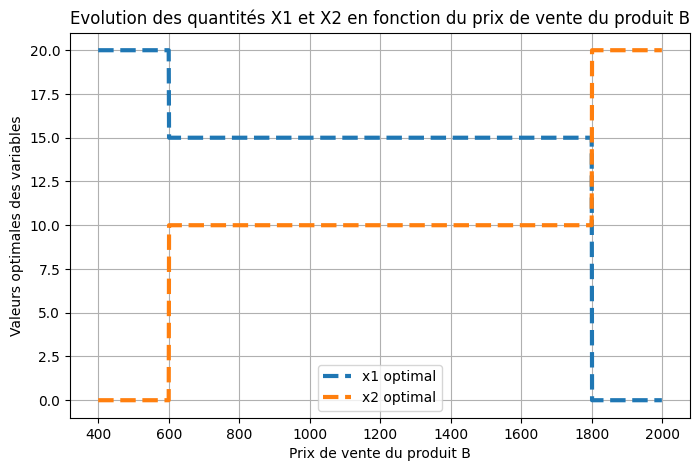

In [10]:
# Intervalle de prix de vente de B
prix_B = np.arange(400, 2000, 1)  # de 400 à 2000 par pas de 1

x1_opt, x2_opt = [], []

# Boucle sur les valeurs de prix_B
for pB in prix_B:
    c_new = [-1200, -pB]  # objectif à maximiser -> on met en négatif
    res = linprog(c_new, A_ub=A, b_ub=b, bounds=bounds, method="highs")
    if res.success:
        x1_opt.append(res.x[0])
        x2_opt.append(res.x[1])
    else:
        x1_opt.append(np.nan)
        x2_opt.append(np.nan)

# Tracé
plt.figure(figsize=(8,5))
plt.plot(prix_B, x1_opt,'--', label="x1 optimal", linewidth=3)
plt.plot(prix_B, x2_opt,'--', label="x2 optimal",linewidth=3)
plt.xlabel("Prix de vente du produit B")
plt.ylabel("Valeurs optimales des variables")
plt.title("Evolution des quantités X1 et X2 en fonction du prix de vente du produit B")
plt.legend()
plt.grid(True)
plt.show()

**Interprétation:**

Le graphique montre comment les quantités optimales à produire pour le Produit A ($x_1$) et le Produit B ($x_2$) évoluent en fonction du prix de vente du Produit B.

*   **Pour des prix de vente de B inférieurs à environ 800 TND :** La quantité optimale de Produit B ($x_2$) est de 0. Cela suggère que pour des prix bas, il n'est pas rentable de produire le Produit B, et la production est concentrée sur le Produit A. La quantité optimale de Produit A ($x_1$) est alors déterminée par les autres contraintes.
*   **Pour des prix de vente de B entre environ 800 TND et 1600 TND :** Les quantités optimales de Produit A et Produit B changent progressivement. À mesure que le prix de B augmente dans cet intervalle, la quantité optimale de B augmente, tandis que celle de A diminue. Cela indique que le Produit B devient plus attrayant à produire à mesure que son prix augmente, et la société ajuste sa production en conséquence pour maximiser le chiffre d'affaires.
*   **Pour des prix de vente de B supérieurs à environ 1600 TND :** La quantité optimale de Produit A ($x_1$) devient 0. Cela signifie que pour des prix élevés de B, il devient optimal de ne produire que le Produit B.

En résumé, ce graphique illustre les seuils de prix pour le Produit B où la stratégie de production optimale de l'entreprise change. Il montre que la rentabilité relative des produits influence fortement les décisions de production.

### **2- Analyse de sensibilité sur le stock de la matière première M1 :**

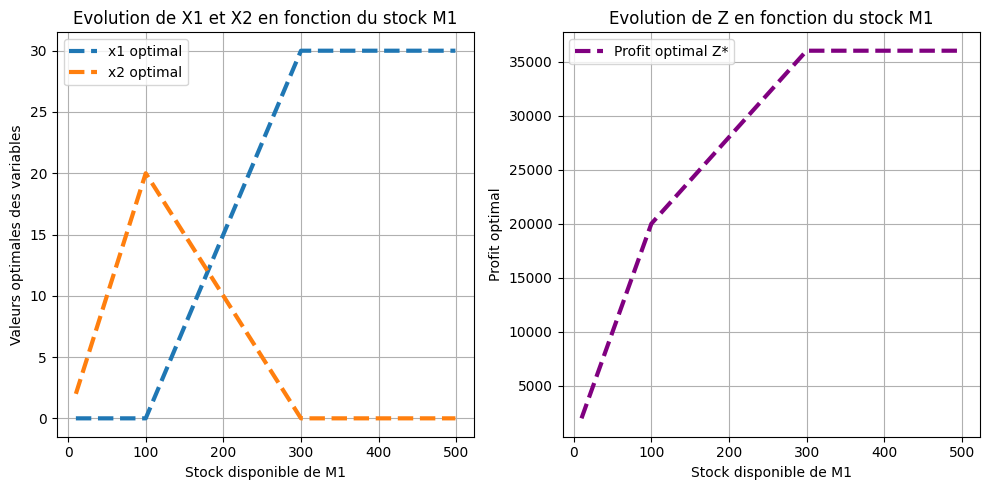

In [11]:
# Intervalle pour le stock de M1
M1_values = np.arange(10, 500, 1)  # de 10 à 500 unités

x1_opt, x2_opt, Z_opt = [], [], []

b_new=b.copy()
for M1 in M1_values:
    b_new[0] = M1  # mise à jour de la contrainte de stock M1
    res = linprog(c, A_ub=A, b_ub=b_new, bounds=bounds, method="highs")

    if res.success:
        x1_opt.append(res.x[0])
        x2_opt.append(res.x[1])
        Z_opt.append(-res.fun)
    else:
        x1_opt.append(np.nan)
        x2_opt.append(np.nan)
        Z_opt.append(np.nan)

# Tracés
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(M1_values, x1_opt,'--', label="x1 optimal", linewidth=3)
plt.plot(M1_values, x2_opt,'--', label="x2 optimal", linewidth=3)
plt.xlabel("Stock disponible de M1")
plt.ylabel("Valeurs optimales des variables")
plt.title("Evolution de X1 et X2 en fonction du stock M1")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(M1_values, Z_opt,'--', label="Profit optimal Z*", color="purple", linewidth=3)
plt.xlabel("Stock disponible de M1")
plt.ylabel("Profit optimal")
plt.title("Evolution de Z en fonction du stock M1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Interprétation:**

Les graphiques illustrent l'impact de la variation du stock disponible de la matière première M1 sur les quantités optimales à produire ($x_1$ et $x_2$) et sur le profit optimal ($Z$).

*   **Graphique de l'évolution de X1 et X2 en fonction du stock M1 :**
    *   Pour de faibles stocks de M1, la production des deux produits est limitée par la disponibilité de M1. À mesure que le stock de M1 augmente, les quantités optimales de $x_1$ et $x_2$ augmentent également, mais pas nécessairement de manière linéaire.
    *   Il existe des points de basculement où la pente des courbes change. Ces points correspondent aux moments où une autre contrainte (M2 ou M3) devient active et commence à limiter la production.
    *   Au-delà d'un certain niveau de stock de M1 (environ 200 kg), l'augmentation de M1 n'a plus d'impact sur les quantités optimales de $x_1$ et $x_2$. Cela indique que d'autres contraintes sont devenues les facteurs limitants.

*   **Graphique de l'évolution de Z en fonction du stock M1 :**
    *   Le profit optimal ($Z$) augmente avec l'augmentation du stock de M1, tant que M1 est une ressource limitante. La pente de cette courbe représente le coût marginal (shadow price) de M1 dans l'intervalle considéré.
    *   Lorsque M1 n'est plus une contrainte active, la courbe de profit devient plate. Cela signifie qu'augmenter davantage le stock de M1 n'augmentera pas le profit maximal, car d'autres ressources sont devenues les goulots d'étranglement.

En résumé, ces graphiques montrent qu'une augmentation de la disponibilité de M1 est bénéfique pour le profit et les quantités produites jusqu'à un certain point, après quoi d'autres contraintes deviennent prédominantes. Le point où la courbe de profit s'aplatit correspond au niveau de stock de M1 au-delà duquel il n'est plus rentable d'acquérir plus de cette matière première (en supposant que les coûts marginaux restent valables).

## **VII- Exercice Asynchrone :**

Revenons au problème de l'agriculteur (étudié dans le cours) modélisé par le PL suivant :

$$\max Z= 100x+200 y $$
$$\text{(surface totale)}\quad x+y\leq 150 $$
$$\text{(quantité d'eau)}\quad 4x+2y\leq 440 $$
$$\text{(main d'oeuvre)}\quad x+4y\leq 480 $$
$$\text{(permission)}\quad x\leq 90 $$
$$x\geq 0, \, y\geq 0 $$

avec $x$ et $y$ représentent respectivement les surfaces à louer pour la culture de tomates et de piments.


###### **1) Résoudre le programme linéaire.**

In [13]:
# Coefficients of the objective function (maximize Z = 100x + 200y -> minimize -Z = -100x - 200y)
c_farmer = [-100, -200]

# Inequality constraint matrix A_ub
A_ub_farmer = [
    [1, 1],   # x + y <= 150 (total surface)
    [4, 2],   # 4x + 2y <= 440 (water quantity)
    [1, 4],   # x + 4y <= 480 (labor)
    [1, 0]    # x <= 90 (permission)
]

# Upper bounds b_ub for the constraints
b_ub_farmer = [150, 440, 480, 90]

# Bounds for the variables (non-negativity)
bounds_farmer = [(0, None), (0, None)] # x >= 0, y >= 0

# Solve the linear programming problem
result_farmer = linprog(c_farmer, A_ub=A_ub_farmer, b_ub=b_ub_farmer, bounds=bounds_farmer, method='highs')

# Check if the optimization was successful and print the results
if result_farmer.success:
    print("Optimization successful:")
    print("Optimal values of x and y:", result_farmer.x)
    print("Maximum profit:", -result_farmer.fun) # Negate the result to get maximum profit
else:
    print("Optimization failed:")
    print(result_farmer.message)

Optimization successful:
Optimal values of x and y: [ 40. 110.]
Maximum profit: 26000.0


###### **2) De combien peut-on modifier la quantité de $m^3$ d’eau sans nuire à la solution optimale ?**

In [22]:
from scipy.optimize import linprog
import numpy as np

# -----------------------------
# 1️⃣ Définition du problème
# -----------------------------

# Fonction objectif (max Z = 100x + 200y → linprog minimise, donc on prend -c)
c = [-100, -200]

# Contraintes sous forme A_ub * x <= b_ub
A = [
    [1, 1],    # surface totale: x + y <= 150
    [4, 2],    # quantité d'eau: 4x + 2y <= 440
    [1, 4],    # main d'oeuvre: x + 4y <= 480
    [1, 0]     # permission: x <= 90
]

b = [150, 440, 480, 90]

# Bornes sur les variables x et y
bounds = [(0, None), (0, None)]

# -----------------------------
# 2️⃣ Résolution du PL
# -----------------------------
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

if result.success:
    x_opt, y_opt = result.x
    Z_opt = -result.fun  # rappel: on a minimisé -Z
    print("=== Solution optimale ===")
    print(f"x* (tomates) = {x_opt:.2f} ha")
    print(f"y* (piments) = {y_opt:.2f} ha")
    print(f"Profit maximal Z* = {Z_opt:.2f}")

    # Slacks
    print("\n=== Marges (slacks) ===")
    for i, slack in enumerate(result.slack):
        print(f"Contrainte {i+1} slack = {slack:.2f}")

    # Shadow prices (HiGHS)
    if hasattr(result, 'pi'):
        print("\n=== Shadow prices (prix ombrage) ===")
        for i, pi in enumerate(result.pi):
            print(f"Contrainte {i+1} shadow price = {pi:.2f}")
    else:
        print("\nShadow prices non disponibles avec cette méthode.")
else:
    print("La résolution a échoué :", result.message)

# -----------------------------
# 3️⃣ Analyse de sensibilité pour la contrainte eau
# -----------------------------
def test_water_range(b_water):
    b_test = b.copy()
    b_test[1] = b_water
    res = linprog(c, A_ub=A, b_ub=b_test, bounds=bounds, method='highs')
    if res.success:
        return res.x, -res.fun
    else:
        return None, None

# On teste des variations autour de 440
delta_range = range(-50, 51, 1)  # tester de -50 à +50 m3
x0, y0 = x_opt, y_opt
Z0 = Z_opt

lower_bound, upper_bound = None, None

for delta in delta_range:
    x_test, Z_test = test_water_range(440 + delta)
    if x_test is not None:
        # comparer avec solution optimale initiale
        if np.allclose([x_test[0], x_test[1]], [x0, y0], atol=1e-2):
            if delta < 0:
                lower_bound = 440 + delta
            elif delta > 0:
                upper_bound = 440 + delta
        else:
            break

print("\n=== Plage autorisée pour la quantité d'eau ===")
print(f"Original water quantity: {b[1]} m^3")
print(f"Allowable range: [{lower_bound} m^3, {upper_bound} m^3]")
print(f"Allowable decrease: {b[1] - lower_bound} m^3")
print(f"Allowable increase: {upper_bound - b[1]} m^3")

=== Solution optimale ===
x* (tomates) = 40.00 ha
y* (piments) = 110.00 ha
Profit maximal Z* = 26000.00

=== Marges (slacks) ===
Contrainte 1 slack = 0.00
Contrainte 2 slack = 60.00
Contrainte 3 slack = 0.00
Contrainte 4 slack = 50.00

Shadow prices non disponibles avec cette méthode.

=== Plage autorisée pour la quantité d'eau ===
Original water quantity: 440 m^3
Allowable range: [439 m^3, 490 m^3]
Allowable decrease: 1 m^3
Allowable increase: 50 m^3


En résumé : la solution optimale est assez robuste aux augmentations d’eau mais très sensible à une diminution.

###### **3) L'agriculteur cherche le volume horaire de main d'oeuvre suffisant pour maximiser le profit. Aider le.**

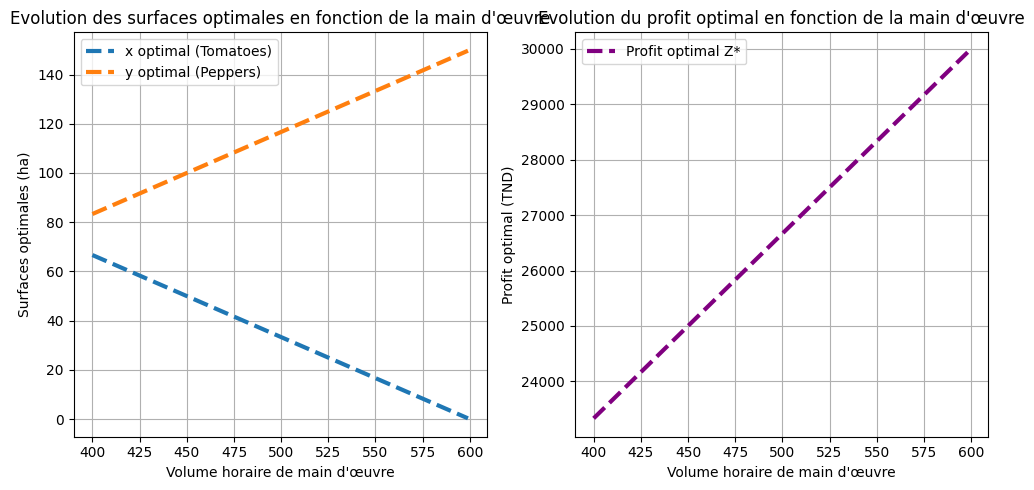

**Interprétation:**

Les graphiques illustrent l'impact de la variation du volume horaire de main d'œuvre disponible sur les surfaces optimales à louer ($x$ et $y$) et sur le profit maximal ($Z$).

*   **Graphique de l'évolution des surfaces optimales en fonction de la main d'œuvre :**
    *   Pour de faibles volumes de main d'œuvre, la production des deux cultures est limitée par la disponibilité de la main d'œuvre. À mesure que le volume de main d'œuvre augmente, les surfaces optimales pour $x$ (tomates) et $y$ (piments) augmentent également.
    *   Il existe un point (autour de 480 heures, qui est la quantité originale) où les courbes de $x$ et $y$ semblent se stabiliser ou changer de pente. Cela indique que la main d'œuvre cesse d'être la contrainte limitante au-delà de ce point. D'autres contraintes (surface totale, eau, ou permission) deviennent alors prédominantes et dictent les surfaces optimales.

*   **Graphique de l'évolution du profit optimal en fonction de la main d'œuvre :**
    *   Le profit maximal ($Z$) augmente avec l'augmentation du volume de main d'œuvre, tant que la main d'œuvre est une ressource limitante. La pente de cette courbe dans cet intervalle correspondrait au coût marginal (shadow price) de la main d'œuvre.
    *   Au-delà du point où la main d'œuvre n'est plus la contrainte la plus restrictive (environ 480 heures), la courbe de profit s'aplatit. Cela signifie qu'augmenter davantage le volume de main d'œuvre n'augmentera pas le profit maximal, car d'autres ressources sont désormais les goulots d'étranglement. Fournir plus de main d'œuvre au-delà de ce point n'est donc pas "suffisant" pour augmenter le profit, car d'autres facteurs limitent la production.

En résumé, les graphiques montrent que l'augmentation de la main d'œuvre est bénéfique pour le profit et les surfaces cultivées jusqu'à un certain point. Le volume horaire de main d'œuvre "suffisant pour maximiser le profit" est le point au-delà duquel le profit n'augmente plus significativement, car d'autres ressources deviennent les contraintes actives. D'après le graphique, ce point semble se situer autour de 480 heures, car au-delà de cette valeur, le profit optimal semble atteindre un plateau.



---



# **Références:**



1.   *Recherche opérationnelle et applications, Bernard Foltz, 2012-2013.*
2.   *Linear Programming and Duality - Indian Institute of Technology (IIT) sur NPTEL.*
3.   *Python for Optimization, par Jesús Rogel-Salazar.*

